In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from mad.utils import load_ballistic_table, BALLISTIC_FIELD_NAMES
from mad.configs.planets import EARTH_SETTINGS
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [35]:
table = load_ballistic_table("rock_no_drag")
df = pd.DataFrame({k:table[:, i] for i, k in enumerate(BALLISTIC_FIELD_NAMES)})

In [36]:

df["range_km"] = df["range_rad"] * EARTH_SETTINGS["radius"] / 1000
df["altitude_km"] = df["altitude_m"] / 1000
df["gamma_deg"] = df["gamma_rad"] * 180 / np.pi


In [40]:
selected_altitude = 0.8
df2 = df[df["altitude_km"] == selected_altitude].pivot(index="velocity_m_s", columns="gamma_deg", values="range_km")
df2


gamma_deg,-20.0,-10.0,0.0,10.0,20.0,30.0,40.0,50.0,60.0,70.0,80.0
velocity_m_s,,,,,,,,,,,
500.0,2.349283,3.446810,6.499747,12.308297,18.786708,23.798198,26.397677,25.990391,22.703027,16.718314,8.919239
1000.0,2.819191,4.924155,12.999481,40.361256,69.445018,90.680127,102.951556,102.194145,89.273012,66.061968,35.056039
1500.0,2.819184,4.431643,20.999407,85.607210,154.588344,206.557238,232.026094,229.988624,201.030467,148.631622,78.610097
2000.0,3.759114,5.909098,27.999130,153.407612,280.399484,373.351885,418.116362,413.354513,358.958873,264.592783,139.839931
2500.0,2.349254,4.924102,34.998786,245.634552,451.832502,597.417145,667.477887,655.247913,565.845306,414.282805,218.506745
3000.0,2.819180,5.909083,41.998357,370.984135,679.007956,889.968745,985.191565,959.489191,823.701460,599.698262,315.330855
3500.0,3.289131,6.894117,52.498301,531.623425,971.699238,1265.448882,1385.595171,1333.536260,1135.123059,820.815889,429.351871
4000.0,3.759108,7.879205,59.997642,747.210440,1351.363183,1740.148739,1876.715447,1784.844009,1501.182392,1078.453690,561.741005
4500.0,4.229110,8.864346,71.997381,1031.505383,1848.409095,2337.477586,2479.122785,2321.053194,1930.611386,1373.075326,711.825414


In [41]:
df[(20 < df["range_km"]) & (df["range_km"] < 30)]

,altitude_m,velocity_m_s,gamma_rad,range_rad,range_km,altitude_km,gamma_deg
104,100.0,500.0,0.523599,0.003532,22.501544,0.1,30.0
105,100.0,500.0,0.698132,0.003963,25.251322,0.1,40.0
106,100.0,500.0,0.872665,0.003979,25.350346,0.1,50.0
107,100.0,500.0,1.047198,0.003485,22.205439,0.1,60.0
167,100.0,3500.0,0.000000,0.003296,20.999988,0.1,0.0
178,100.0,4000.0,0.000000,0.003767,23.999960,0.1,0.0
189,100.0,4500.0,0.000000,0.004238,26.999921,0.1,0.0
203,200.0,500.0,0.523599,0.003532,22.501190,0.2,30.0
204,200.0,500.0,0.698132,0.004024,25.633966,0.2,40.0
205,200.0,500.0,0.872665,0.003979,25.349946,0.2,50.0


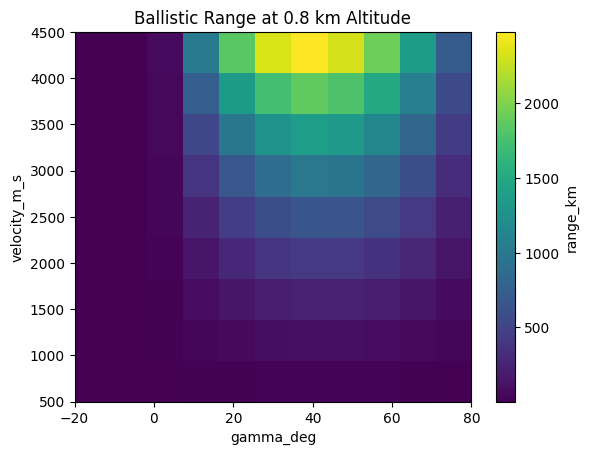

In [42]:
fig, ax = plt.subplots()
img = ax.imshow(df2.values, extent=(df2.columns.min(), df2.columns.max(), df2.index.min(), df2.index.max()), aspect="auto", origin="lower")
ax.set_xlabel("gamma_deg")
ax.set_ylabel("velocity_m_s")
cbar = fig.colorbar(img, ax=ax)
cbar.set_label("range_km")
ax.set_title(f"Ballistic Range at {selected_altitude} km Altitude")
plt.show()